# Analyse de la variable geompoint

Ce notebook analyse la cohérence des coordonnées géographiques dans la colonne `geompoint` du fichier nettoyé.

## 1. Importation des bibliothèques

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Bibliothèques importées avec succès !")

Bibliothèques importées avec succès !


## 2. Chargement des données

In [2]:
# Chargement des données depuis le fichier CSV
df = pd.read_csv('../data/friches-standard-clean.csv', sep=';', encoding='utf-8', low_memory=False)

print(f"Données chargées avec succès !")
print(f"Nombre de lignes : {df.shape[0]:,}")
print(f"Nombre de colonnes : {df.shape[1]}")

Données chargées avec succès !
Nombre de lignes : 28,728
Nombre de colonnes : 34


## 3. Aperçu de la colonne geompoint

In [3]:
# Affichage des premières valeurs de geompoint
print("=== Premières valeurs de geompoint ===")
print(df['geompoint'].head(20))
print(f"\nType de données : {df['geompoint'].dtype}")
print(f"Nombre de valeurs uniques : {df['geompoint'].nunique():,}")
print(f"Valeurs manquantes : {df['geompoint'].isnull().sum()}")

=== Premières valeurs de geompoint ===
0       POINT (3.469862 46.13434)
1       POINT (6.999754 43.58304)
2       POINT (7.203463 43.67994)
3        POINT (1.44829 49.80831)
4       POINT (7.227269 43.71092)
5       POINT (7.089416 48.40237)
6       POINT (7.243596 43.71449)
7       POINT (7.199612 43.68189)
8       POINT (7.286279 43.71845)
9       POINT (2.986941 49.56997)
10      POINT (7.902822 48.76796)
11    POINT (-0.1096779 43.18118)
12      POINT (7.194423 43.66199)
13      POINT (7.450649 48.54036)
14    POINT (-0.5811806 49.25697)
15      POINT (4.667919 45.24651)
16       POINT (4.719171 45.1748)
17      POINT (4.645069 44.37672)
18    POINT (-0.5386609 48.91631)
19      POINT (5.436085 46.09547)
Name: geompoint, dtype: object

Type de données : object
Nombre de valeurs uniques : 27,506
Valeurs manquantes : 0


## 4. Extraction des coordonnées latitude et longitude

In [4]:
# Extraction des coordonnées depuis le format "POINT (longitude latitude)"
def extraire_coordonnees(point_str):
    """Extrait longitude et latitude depuis une chaîne POINT"""
    if pd.isna(point_str):
        return None, None
    try:
        # Retirer "POINT (" et ")"
        coords = point_str.replace('POINT (', '').replace(')', '')
        lon, lat = coords.split()
        return float(lon), float(lat)
    except:
        return None, None

# Application de la fonction
df[['longitude', 'latitude']] = df['geompoint'].apply(
    lambda x: pd.Series(extraire_coordonnees(x))
)

print("✅ Coordonnées extraites avec succès !")
print(f"\nPremières lignes :")
print(df[['geompoint', 'longitude', 'latitude']].head(10))

✅ Coordonnées extraites avec succès !

Premières lignes :
                   geompoint  longitude  latitude
0  POINT (3.469862 46.13434)   3.469862  46.13434
1  POINT (6.999754 43.58304)   6.999754  43.58304
2  POINT (7.203463 43.67994)   7.203463  43.67994
3   POINT (1.44829 49.80831)   1.448290  49.80831
4  POINT (7.227269 43.71092)   7.227269  43.71092
5  POINT (7.089416 48.40237)   7.089416  48.40237
6  POINT (7.243596 43.71449)   7.243596  43.71449
7  POINT (7.199612 43.68189)   7.199612  43.68189
8  POINT (7.286279 43.71845)   7.286279  43.71845
9  POINT (2.986941 49.56997)   2.986941  49.56997


## 5. Statistiques descriptives des coordonnées

In [5]:
# Statistiques des coordonnées
print("=== Statistiques de la LONGITUDE ===")
print(df['longitude'].describe())
print(f"\n=== Statistiques de la LATITUDE ===")
print(df['latitude'].describe())

# Vérification des coordonnées manquantes après extraction
print(f"\n=== Valeurs manquantes après extraction ===")
print(f"Longitude manquante : {df['longitude'].isnull().sum()}")
print(f"Latitude manquante : {df['latitude'].isnull().sum()}")

=== Statistiques de la LONGITUDE ===
count    28727.000000
mean         2.050644
std          4.232074
min        -62.831100
25%          0.146696
50%          1.989254
75%          3.932557
max         55.821130
Name: longitude, dtype: float64

=== Statistiques de la LATITUDE ===
count    28727.000000
mean        47.198312
std          3.583311
min        -21.349540
25%         45.648540
50%         47.975380
75%         49.105110
max         51.061990
Name: latitude, dtype: float64

=== Valeurs manquantes après extraction ===
Longitude manquante : 1
Latitude manquante : 1


## 6. Vérification de la cohérence géographique (France métropolitaine)

In [6]:
# Limites approximatives de la France métropolitaine
# Longitude : -5.5° Ouest à 10° Est
# Latitude : 41° Nord à 51.5° Nord

lon_min, lon_max = -5.5, 10.0
lat_min, lat_max = 41.0, 51.5

# Identification des points hors de France métropolitaine
hors_france = df[
    (df['longitude'] < lon_min) | (df['longitude'] > lon_max) |
    (df['latitude'] < lat_min) | (df['latitude'] > lat_max)
]

print(f"=== Vérification géographique ===")
print(f"Total de points : {len(df):,}")
print(f"Points en France métropolitaine : {len(df) - len(hors_france):,}")
print(f"Points HORS France métropolitaine : {len(hors_france):,} ({len(hors_france)/len(df)*100:.2f}%)")

if len(hors_france) > 0:
    print(f"\n=== Exemples de points hors France métropolitaine ===")
    print(hors_france[['site_nom', 'comm_nom', 'longitude', 'latitude', 'geompoint']].head(10))

=== Vérification géographique ===
Total de points : 28,728
Points en France métropolitaine : 28,638
Points HORS France métropolitaine : 90 (0.31%)

=== Exemples de points hors France métropolitaine ===
                                                site_nom        comm_nom  \
9599   Appel à projet Recyclage Foncier 2021 (Dossier...   Morne-à-l'Eau   
9602   Appel à projet Recyclage Foncier 2021 3ième éd...     Saint-André   
14790  Appel à projet Recyclage Foncier 2021 2nde édi...         Chiconi   
14981     Appel à projet Fonds Vert 2023 -SAINT-FRANCOIS  SAINT-FRANCOIS   
14982  Appel à projet Recyclage Foncier 2021 2nde édi...         Chiconi   
15299  Appel à projet Recyclage Foncier 2021 2nde édi...  Pointe-à-Pitre   
15300  Appel à projet Recyclage Foncier 2021 3ième éd...        Dzaoudzi   
16499  Appel à projet Recyclage Foncier 2021 (Dossier...         Baillif   
16501       Appel à projet Fonds Vert 2023 -BAIE-MAHAULT    BAIE-MAHAULT   
16502  Appel à projet Recyclage Foncie

## 7. Visualisation de la distribution géographique

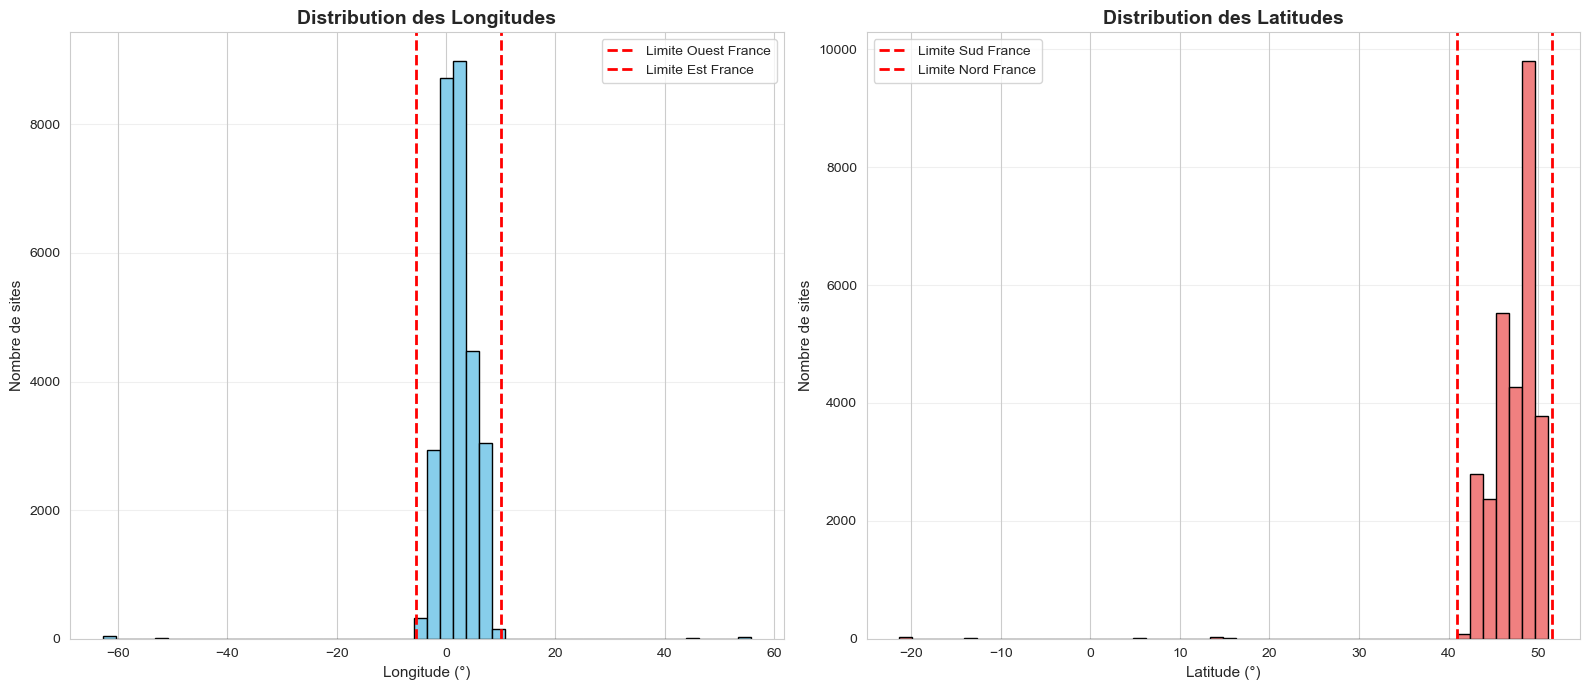

In [7]:
# Graphique de dispersion des coordonnées
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Distribution des longitudes
ax1 = axes[0]
df['longitude'].hist(bins=50, edgecolor='black', color='skyblue', ax=ax1)
ax1.axvline(lon_min, color='red', linestyle='--', linewidth=2, label='Limite Ouest France')
ax1.axvline(lon_max, color='red', linestyle='--', linewidth=2, label='Limite Est France')
ax1.set_title('Distribution des Longitudes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude (°)', fontsize=11)
ax1.set_ylabel('Nombre de sites', fontsize=11)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Distribution des latitudes
ax2 = axes[1]
df['latitude'].hist(bins=50, edgecolor='black', color='lightcoral', ax=ax2)
ax2.axvline(lat_min, color='red', linestyle='--', linewidth=2, label='Limite Sud France')
ax2.axvline(lat_max, color='red', linestyle='--', linewidth=2, label='Limite Nord France')
ax2.set_title('Distribution des Latitudes', fontsize=14, fontweight='bold')
ax2.set_xlabel('Latitude (°)', fontsize=11)
ax2.set_ylabel('Nombre de sites', fontsize=11)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Carte de localisation des friches

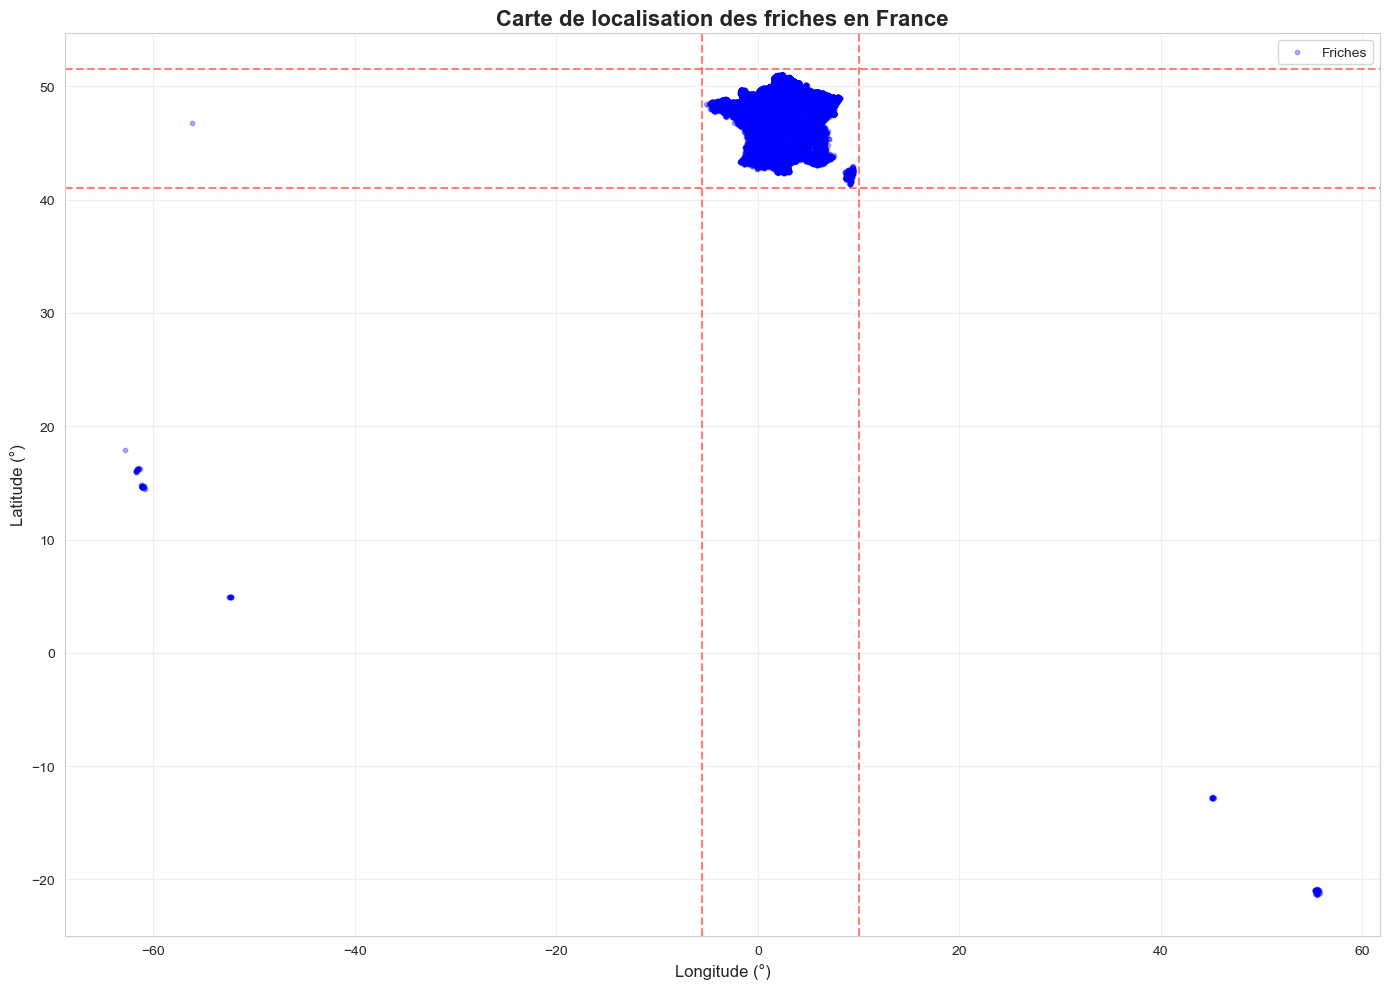


📍 Carte générée avec 28,728 points


In [8]:
# Carte de dispersion des friches sur le territoire français
plt.figure(figsize=(14, 10))

# Tracer tous les points
plt.scatter(df['longitude'], df['latitude'], alpha=0.3, s=10, c='blue', label='Friches')

# Ajouter les limites de la France
plt.axvline(lon_min, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axvline(lon_max, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axhline(lat_min, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
plt.axhline(lat_max, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

plt.title('Carte de localisation des friches en France', fontsize=16, fontweight='bold')
plt.xlabel('Longitude (°)', fontsize=12)
plt.ylabel('Latitude (°)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📍 Carte générée avec {len(df):,} points")

## 9. Détection des valeurs aberrantes

In [10]:
# Détection de valeurs aberrantes (coordonnées inhabituelles)
print("=== Détection des valeurs aberrantes ===")

# Coordonnées nulles ou très proches de zéro
coords_zero = df[(df['longitude'].abs() < 0.1) & (df['latitude'].abs() < 0.1)]
print(f"\n🔍 Coordonnées proches de (0, 0) : {len(coords_zero)}")
if len(coords_zero) > 0:
    print(coords_zero[['site_nom', 'comm_nom', 'longitude', 'latitude']].head())

# Coordonnées inversées (longitude/latitude)
coords_inversees = df[(df['longitude'] > 40) | (df['latitude'] < 0)]
print(f"\n🔍 Coordonnées potentiellement inversées : {len(coords_inversees)}")
if len(coords_inversees) > 0:
    print(coords_inversees[['site_nom', 'comm_nom', 'longitude', 'latitude']].head())

# Doublons de coordonnées exactes
coords_dupliquees = df.groupby(['longitude', 'latitude']).size().reset_index(name='count')
coords_dupliquees = coords_dupliquees[coords_dupliquees['count'] > 1].sort_values('count', ascending=False)
print(f"\n🔍 Paires de coordonnées dupliquées : {len(coords_dupliquees)}")
print(f"Nombre total de sites avec coordonnées dupliquées : {coords_dupliquees['count'].sum():,}")
print("\nTop 10 des coordonnées les plus dupliquées :")
print(coords_dupliquees.head(10))

=== Détection des valeurs aberrantes ===

🔍 Coordonnées proches de (0, 0) : 0

🔍 Coordonnées potentiellement inversées : 39
                                                site_nom     comm_nom  \
9602   Appel à projet Recyclage Foncier 2021 3ième éd...  Saint-André   
14790  Appel à projet Recyclage Foncier 2021 2nde édi...      Chiconi   
14982  Appel à projet Recyclage Foncier 2021 2nde édi...      Chiconi   
15300  Appel à projet Recyclage Foncier 2021 3ième éd...     Dzaoudzi   
16525  Appel à projet Recyclage Foncier 2021 2nde édi...   Bras-Panon   

       longitude  latitude  
9602    55.64833 -20.95016  
14790   45.10666 -12.82197  
14982   45.11599 -12.83214  
15300   45.26415 -12.78748  
16525   55.66700 -21.00062  

🔍 Paires de coordonnées dupliquées : 901
Nombre total de sites avec coordonnées dupliquées : 2,123

Top 10 des coordonnées les plus dupliquées :
       longitude  latitude  count
25010   6.197923  48.67861     17
26525   7.286279  43.71845     13
4617   -0.53888

## 10. Résumé de la cohérence des données géographiques

In [11]:
# Résumé final
print("="*60)
print("        RÉSUMÉ DE LA COHÉRENCE DES DONNÉES GÉOGRAPHIQUES")
print("="*60)

# Recalcul des statistiques pour cette cellule autonome
total = len(df)
valides = len(df) - len(hors_france)
invalides = len(hors_france)

# Recalcul des valeurs aberrantes
coords_zero = df[(df['longitude'].abs() < 0.1) & (df['latitude'].abs() < 0.1)]
coords_inversees = df[(df['longitude'] > 40) | (df['latitude'] < 0)]
coords_dupliquees = df.groupby(['longitude', 'latitude']).size().reset_index(name='count')
coords_dupliquees = coords_dupliquees[coords_dupliquees['count'] > 1]

print(f"\n📊 STATISTIQUES GLOBALES :")
print(f"   Total de sites : {total:,}")
print(f"   Sites avec coordonnées valides : {valides:,} ({valides/total*100:.2f}%)")
print(f"   Sites hors France métropolitaine : {invalides:,} ({invalides/total*100:.2f}%)")

print(f"\n📍 PLAGES DE COORDONNÉES :")
print(f"   Longitude : {df['longitude'].min():.4f}° à {df['longitude'].max():.4f}°")
print(f"   Latitude : {df['latitude'].min():.4f}° à {df['latitude'].max():.4f}°")

print(f"\n⚠️  PROBLÈMES DÉTECTÉS :")
print(f"   Valeurs manquantes : {df['longitude'].isnull().sum()}")
print(f"   Coordonnées hors France : {len(hors_france)}")
print(f"   Coordonnées proches de (0,0) : {len(coords_zero)}")
print(f"   Coordonnées potentiellement inversées : {len(coords_inversees)}")
print(f"   Coordonnées dupliquées : {len(coords_dupliquees)} paires")

print(f"\n✅ CONCLUSION :")
if invalides == 0 and len(coords_zero) == 0 and len(coords_inversees) == 0:
    print("   Les données géographiques sont cohérentes et complètes !")
elif invalides / total < 0.05:
    print("   Les données géographiques sont globalement bonnes.")
    print("   Quelques anomalies mineures détectées (< 5%).")
else:
    print("   Attention : plusieurs anomalies détectées dans les coordonnées.")
    print("   Un nettoyage supplémentaire pourrait être nécessaire.")

print("="*60)

        RÉSUMÉ DE LA COHÉRENCE DES DONNÉES GÉOGRAPHIQUES

📊 STATISTIQUES GLOBALES :
   Total de sites : 28,728
   Sites avec coordonnées valides : 28,638 (99.69%)
   Sites hors France métropolitaine : 90 (0.31%)

📍 PLAGES DE COORDONNÉES :
   Longitude : -62.8311° à 55.8211°
   Latitude : -21.3495° à 51.0620°

⚠️  PROBLÈMES DÉTECTÉS :
   Valeurs manquantes : 1
   Coordonnées hors France : 90
   Coordonnées proches de (0,0) : 0
   Coordonnées potentiellement inversées : 39
   Coordonnées dupliquées : 901 paires

✅ CONCLUSION :
   Les données géographiques sont globalement bonnes.
   Quelques anomalies mineures détectées (< 5%).


## 11. Exportation du fichier avec coordonnées géographiques séparées

In [12]:
# Création du nouveau fichier CSV avec colonnes longitude et latitude
output_file = '../data/friches-standard-geom.csv'

# Suppression de la colonne geompoint originale (optionnel, on garde les deux pour l'instant)
# On réorganise les colonnes pour mettre longitude et latitude après site_id
colonnes = df.columns.tolist()

# Retirer longitude et latitude de leur position actuelle
colonnes = [col for col in colonnes if col not in ['longitude', 'latitude']]

# Les insérer après site_id (position 1)
colonnes.insert(1, 'longitude')
colonnes.insert(2, 'latitude')

# Réorganiser le DataFrame
df_export = df[colonnes]

# Exportation
df_export.to_csv(output_file, sep=';', index=False, encoding='utf-8')

print(f"✅ Fichier exporté avec succès !")
print(f"\n📁 Fichier : {output_file}")
print(f"📊 Statistiques :")
print(f"   - Lignes : {df_export.shape[0]:,}")
print(f"   - Colonnes : {df_export.shape[1]}")
print(f"   - Taille estimée : {df_export.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n📍 Colonnes géographiques ajoutées :")
print(f"   - longitude (colonne 2)")
print(f"   - latitude (colonne 3)")
print(f"   - geompoint (conservé pour référence)")

✅ Fichier exporté avec succès !

📁 Fichier : ../data/friches-standard-geom.csv
📊 Statistiques :
   - Lignes : 28,728
   - Colonnes : 36
   - Taille estimée : 65.48 MB

📍 Colonnes géographiques ajoutées :
   - longitude (colonne 2)
   - latitude (colonne 3)
   - geompoint (conservé pour référence)


In [13]:
# Vérification du fichier exporté
print("=== Aperçu des premières lignes du fichier exporté ===\n")
print(df_export[['site_id', 'longitude', 'latitude', 'site_nom', 'comm_nom', 'geompoint']].head(10))

=== Aperçu des premières lignes du fichier exporté ===

       site_id  longitude  latitude  \
0  03095_17913   3.469862  46.13434   
1  06085_16087   6.999754  43.58304   
2  06088_10998   7.203463  43.67994   
3  76175_26890   1.448290  49.80831   
4  06088_16211   7.227269  43.71092   
5  52465_36246   7.089416  48.40237   
6  06088_29121   7.243596  43.71449   
7   06088_6374   7.199612  43.68189   
8   06088_9317   7.286279  43.71845   
9  60506_36042   2.986941  49.56997   

                                            site_nom       comm_nom  \
0             Anc. Décharge Communale OM de Meunière         CUSSET   
1                               Serrurerie et garage        MOUGINS   
2  Appel à projet Recyclage Foncier 2021 2nde édi...           NICE   
3                           Maison rue du val Ricard          Clais   
4                                      Blanchisserie           NICE   
5                            Auberge du Col du Hantz      Saulxures   
6                

### 📋 Résumé de l'export

Le fichier **`friches-standard-geom.csv`** est maintenant prêt pour :
- ✅ Import dans MariaDB/MySQL
- ✅ Utilisation dans une application PHP
- ✅ Affichage sur une carte interactive (Leaflet.js, OpenLayers, etc.)

**Avantages du nouveau format :**
- Colonnes `longitude` et `latitude` directement exploitables
- Compatible avec les requêtes SQL géospatiales
- Facile à utiliser avec JavaScript pour les cartes interactives
- Format optimal pour les filtres géographiques (sélection de zone)